In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")


df = pd.read_csv("IPL.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [7]:
print(f"rows : {df.shape[0]} and columns : {df.shape[1]}")

rows : 74 and columns : 20


In [8]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [10]:
match_wins = df["match_winner"].value_counts()

<Axes: ylabel='match_winner'>

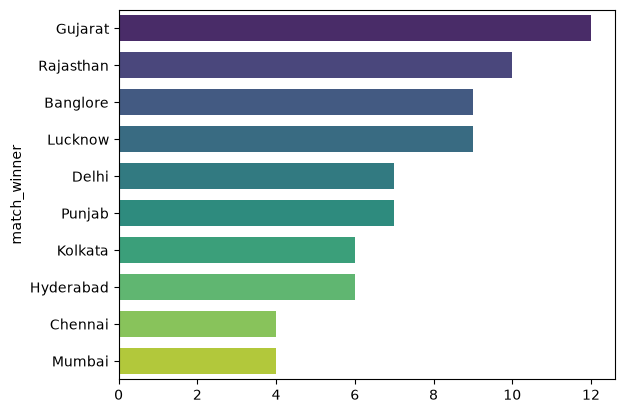

In [19]:
sns.barplot(y = match_wins.index,x=match_wins.values,width=0.7,palette = 'viridis')

Most Match Wins

<Axes: xlabel='toss_decision', ylabel='count'>

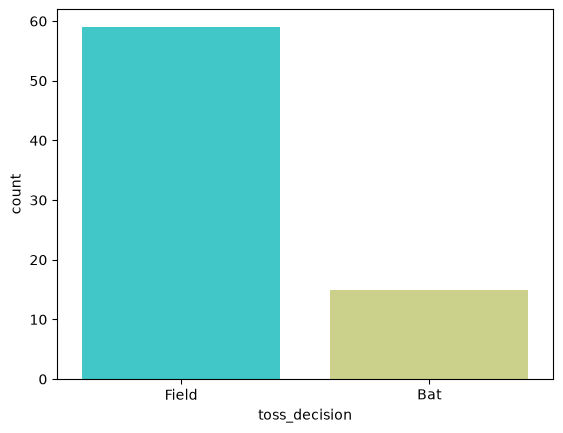

In [22]:
sns.countplot(x = df["toss_decision"],palette="rainbow")

In [29]:
count = df[df["toss_winner"] == df["match_winner"]]["match_id"].count()
percentage = (count*100)/df.shape[0] 
percentage.round(2)

np.float64(48.65)

Toss_winner Vs Match_winner Percentage

<Axes: xlabel='won_by', ylabel='count'>

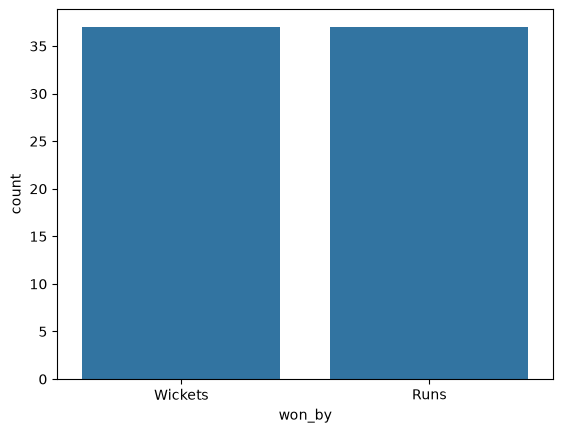

In [32]:
sns.countplot(x=df["won_by"])

In [37]:
count = df["player_of_the_match"].value_counts().head(10)
count

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Name: count, dtype: int64

<Axes: ylabel='player_of_the_match'>

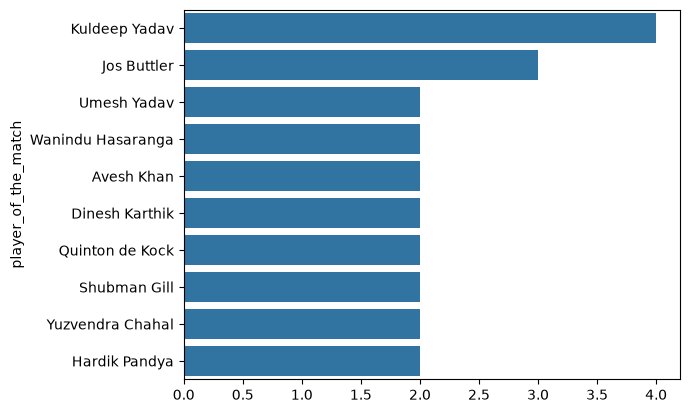

In [39]:
sns.barplot(y =count.index , x = count.values)

Players who won player of the match most times

In [47]:
top_scorers = df["top_scorer"].value_counts().head(10)

top_scorer
Jos Buttler         7
Quinton de Kock     5
Shubman Gill        4
Liam Livingstone    4
KL Rahul            4
Ishan Kishan        3
Faf du Plessis      3
David Warner        3
W. Saha             3
MS Dhoni            2
Name: count, dtype: int64

In [52]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

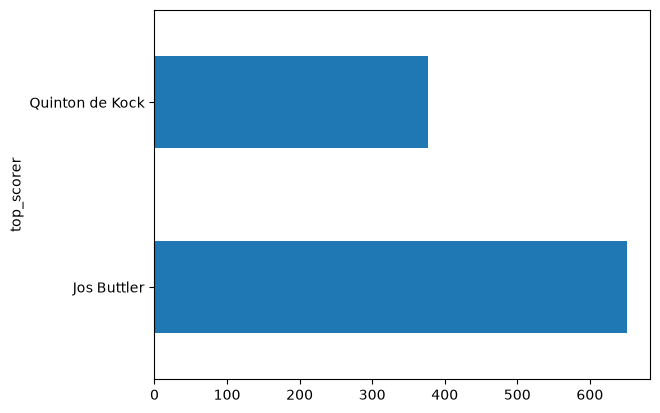

In [54]:
high.plot(kind='barh')

Top Highscorers 

<Axes: ylabel='best_bowling'>

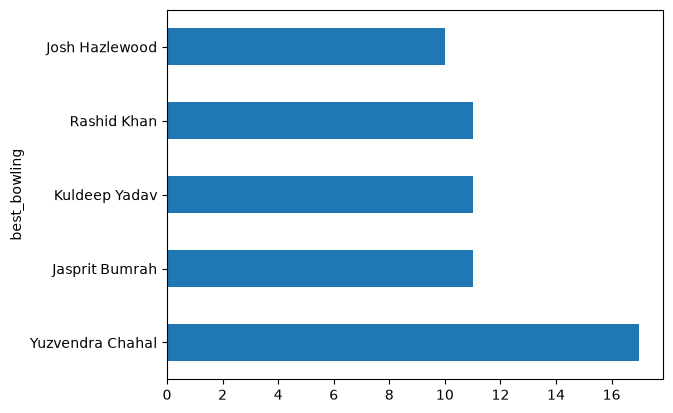

In [65]:
highest = df['Highest_Wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['Highest_Wickets'] = df['Highest_Wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['Highest_Wickets'].sum().sort_values(ascending = False).head(5)
top_bowlers.plot(kind = 'barh')

<Axes: ylabel='venue'>

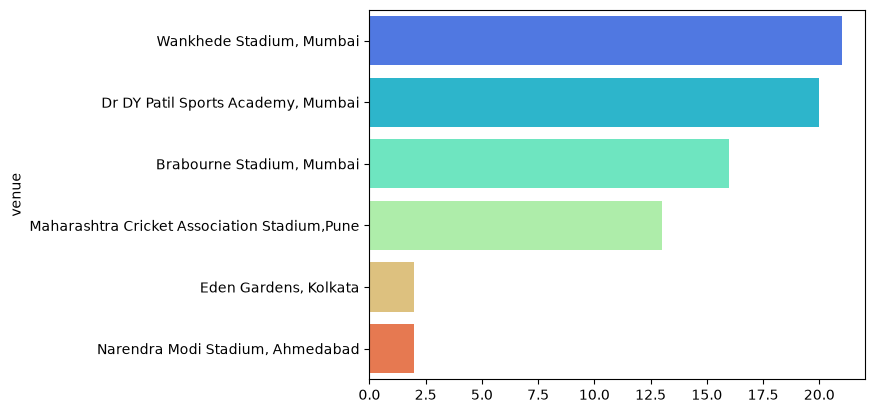

In [72]:
venue_count = df['venue'].value_counts()
sns.barplot(y = venue_count.index , x = venue_count.values , palette = 'rainbow')

Wankhede Stadium venue had most matches  

In [76]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin',ascending = False).head(1)[['team1' , 'margin']]

,team1,margin
54,Chennai,91


Chennai won the highest margin by runs

In [81]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Quinton de Kock	had the highest individual score

In [86]:
df[df['Highest_Wickets'] == df['Highest_Wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
